In [20]:
# M3 - Random Forest + Target Encoding + Optuna Tuning
#
# ⚠️  DÉPENDANCES REQUISES :
# pip install category_encoders optuna
#
# Changements majeurs par rapport à la v1 :
# - ✅ OneHotEncoder → TargetEncoder (categorical_encoders)
#   → Plus compact, pas d'explosion dimensionnelle
#   → Mieux adapté au RandomForest
# - ✅ RandomizedSearchCV → Optuna avec pruning et early stopping
#   → Recherche bayésienne + arrêt automatique si pas d'amélioration
#
# 1. IMPORTATIONS POUR LE M3 (Sélection + Random Forest)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned


In [21]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
# Toujours le log pour Kaggle !
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [22]:
# 3. CRÉATION DU PREPROCESSOR (RobustScaler + Target Encoding)
#
# Remplacement de OneHotEncoder par TargetEncoding :
# - Plus compact (pas d'explosion dimensionnelle)
# - Mieux adapté au RandomForest que les variables binaires OHE
# - Les catégories sont encodées par la moyenne conditionnelle de la target
# - Smoothing=10 régularise pour éviter overfitting sur catégories rares

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [23]:
# 3bis. DIAGNOSTIC DU TARGET ENCODING
# Affichage des colonnes catégorielles et vérification du preprocessing

print("=" * 60)
print("DIAGNOSTIC DU PREPROCESSING (Target Encoding)")
print("=" * 60)
print(f"\n📊 Variables numériques : {len(numeric_features)}")
print(f"   {list(numeric_features)[:5]}... (affichage tronqué)\n")

print(f"📂 Variables catégorielles : {len(categorical_features)}")
for col in categorical_features:
    card = X_train[col].nunique()
    print(f"   {col:20} → cardinalité: {card:3} (top: {X_train[col].value_counts().index[0]})")

print(f"\n✔️  Target Encoding va traduire chaque catégorie en score numérique")
print(f"   (moyenne conditionnelle de SalePrice Log avec régularisation smoothing=10)")
print("=" * 60)

DIAGNOSTIC DU PREPROCESSING (Target Encoding)

📊 Variables numériques : 36
   ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']... (affichage tronqué)

📂 Variables catégorielles : 43
   MSZoning             → cardinalité:   5 (top: RL)
   Street               → cardinalité:   2 (top: Pave)
   Alley                → cardinalité:   2 (top: Grvl)
   LotShape             → cardinalité:   4 (top: Reg)
   LandContour          → cardinalité:   4 (top: Lvl)
   Utilities            → cardinalité:   2 (top: AllPub)
   LotConfig            → cardinalité:   5 (top: Inside)
   LandSlope            → cardinalité:   3 (top: Gtl)
   Neighborhood         → cardinalité:  25 (top: NAmes)
   Condition1           → cardinalité:   9 (top: Norm)
   Condition2           → cardinalité:   8 (top: Norm)
   BldgType             → cardinalité:   5 (top: 1Fam)
   HouseStyle           → cardinalité:   8 (top: 1Story)
   RoofStyle            → cardinalité:   6 (top: Gable)
   RoofMatl            

In [24]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M3)

# Étape A : Le Filtre Lasso
# SelectFromModel va utiliser un LassoCV en interne. Il gardera uniquement les variables dont le coefficient n'a pas été réduit à 0.
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : Le Modèle Random Forest (Artillerie lourde)
# On initialise une Forêt Aléatoire de base
rf_model = RandomForestRegressor(random_state=42)

# Étape C : Assemblage de la Super Pipeline
pipeline_m3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_model)
])

# Étape D : Optimisation avec Optuna (plus intelligent que RandomizedSearchCV)
def objective(trial):
    """
    Fonction objective pour Optuna : teste différentes combos d'hyperparamètres
    et retourne le RMSE moyen en validation croisée.

    Implémentation avec boucle CV manuelle pour pouvoir "report" et permettre
    le pruning par Optuna (ex: MedianPruner). On utilise KFold pour générer
    des scores intermédiaires.
    """
    # Optuna suggère les hyperparamètres
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    # Créer une nouvelle pipeline avec ces hyperparamètres
    rf_model_trial = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    pipeline_trial = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('rf', rf_model_trial)
    ])

    # Boucle CV manuelle pour pouvoir reporter les scores de chaque fold
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline_trial.fit(X_tr, y_tr)
        preds = pipeline_trial.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        neg_rmse = -rmse  # on garde la convention 'plus grand = meilleur'
        fold_scores.append(neg_rmse)

        # Report pour le pruner d'Optuna
        trial.report(neg_rmse, step=fold_idx)
        if trial.should_prune():
            raise TrialPruned()

    # Retourner la moyenne négative du RMSE (direction maximize)
    return float(np.mean(fold_scores))


# Étape E : Lancement de l'étude Optuna
print("Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...")
print("Cela va tester jusqu'à 50 combinaisons mais pourra s'arrêter plus tôt si inutile...\n")

# Sampler Bayésien (TPE = Tree-structured Parzen Estimator) et pruner
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_warmup_steps=5)

# Callback pour stopper l'étude si pas d'amélioration sur N trials consécutifs
def stop_if_no_improvement_factory(patience=10):
    state = {'best_value': None, 'no_improve': 0}

    def _callback(study, trial):
        # study.best_value suit la direction (ici maximize)
        if state['best_value'] is None or study.best_value > state['best_value']:
            state['best_value'] = study.best_value
            state['no_improve'] = 0
        else:
            state['no_improve'] += 1

        if state['no_improve'] >= patience:
            print(f"Aucun progrès depuis {patience} essais — arrêt de l'étude Optuna.")
            study.stop()

    return _callback

early_stop_callback = stop_if_no_improvement_factory(patience=10)

study = optuna.create_study(
    direction='maximize',  # On maximise car on retourne neg_rmse
    sampler=sampler,
    pruner=pruner
)

# Lancement de l'optimisation avec callback d'arrêt anticipé
study.optimize(objective, n_trials=50, callbacks=[early_stop_callback], show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)

# Réentraîner le meilleur modèle avec les meilleurs paramètres
best_params = study.best_params
rf_best = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42,
    n_jobs=-1
)

best_m3_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_best)
])

# Fit sur tout le train set
best_m3_pipeline.fit(X_train, y_train)

# Évaluation sur le Train Set
y_pred_train = best_m3_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

[I 2026-05-21 17:08:15,088] A new study created in memory with name: no-name-79abd2f0-165a-478f-8007-239f73453d2a


Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...
Cela va tester jusqu'à 50 combinaisons mais pourra s'arrêter plus tôt si inutile...



Best trial: 0. Best value: -0.144663:   2%|▏         | 1/50 [00:01<01:08,  1.41s/it]

[I 2026-05-21 17:08:16,494] Trial 0 finished with value: -0.14466272540339561 and parameters: {'n_estimators': 200, 'max_depth': 48, 'min_samples_split': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.14466272540339561.


Best trial: 0. Best value: -0.144663:   4%|▍         | 2/50 [00:02<00:59,  1.24s/it]

...

[I 2026-05-21 17:08:42,471] Trial 15 finished with value: -0.13994228537024025 and parameters: {'n_estimators': 450, 'max_depth': 37, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 7 with value: -0.13988843269793014.


Best trial: 7. Best value: -0.139888:  34%|███▍      | 17/50 [00:29<01:03,  1.93s/it]

[I 2026-05-21 17:08:44,537] Trial 16 finished with value: -0.1409503791634064 and parameters: {'n_estimators': 450, 'max_depth': 42, 'min_samples_split': 5, 'max_features': 'sqrt'}. Best is trial 7 with value: -0.13988843269793014.


Best trial: 7. Best value: -0.139888:  36%|███▌      | 18/50 [00:31<00:56,  1.75s/it]


[I 2026-05-21 17:08:46,604] Trial 17 finished with value: -0.14206721848193307 and parameters: {'n_estimators': 450, 'max_depth': 21, 'min_samples_split': 9, 'max_features': 'sqrt'}. Best is trial 7 with value: -0.13988843269793014.
Aucun progrès depuis 10 essais — arrêt de l'étude Optuna.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.1399
Meilleurs hyperparamètres trouvés :
{'n_estimators': 450, 'max_depth': 19, 'min_samples_split': 3, 'max_features': 'sqrt'}
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.0544


In [25]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m3 = best_m3_pipeline.predict(X_test)
preds_dollars_m3 = np.expm1(preds_log_m3) # Retour au prix en dollars

submission_m3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m3
})

fichier_soumission = 'M3_RandomForest_Submission.csv'
submission_m3.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M3_RandomForest_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


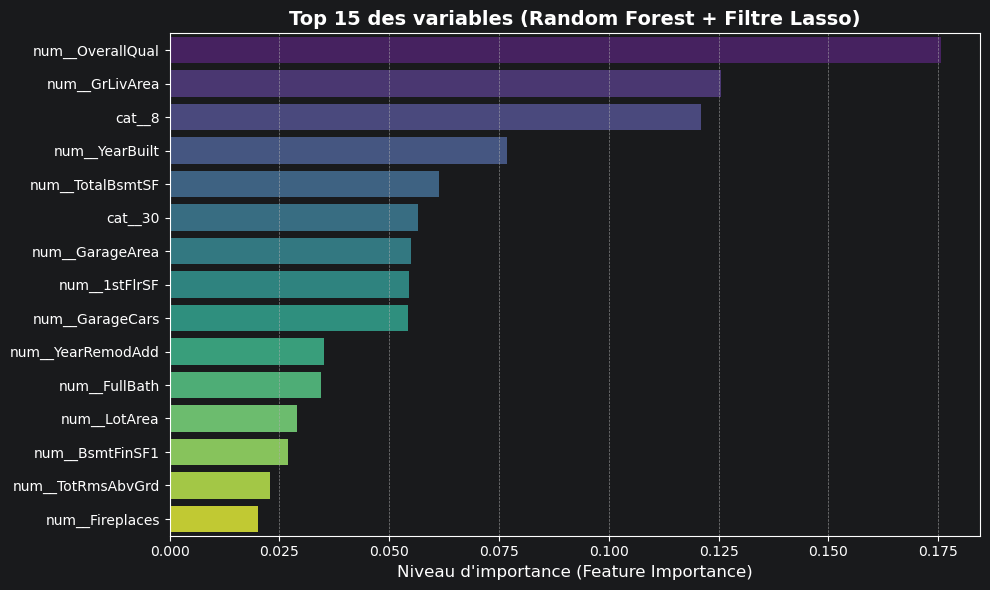

In [26]:
# 6. VISUALISATION : COMMENT LA FORÊT PREND SES DÉCISIONS ?

# Pour un Random Forest, l'importance des variables n'est pas "positive ou négative"
# comme un Lasso. C'est un pourcentage d'importance globale (de 0 à 1).

# 1. Récupérer toutes les variables créées par le preprocessor
toutes_variables = best_m3_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Récupérer le filtre (quelles variables le Lasso a laissé passer ?)
masque_lasso = best_m3_pipeline.named_steps['selector'].get_support()
variables_filtrees = toutes_variables[masque_lasso]

# 3. Récupérer l'importance donnée par le Random Forest
rf_importances = best_m3_pipeline.named_steps['rf'].feature_importances_

# 4. Créer le DataFrame et prendre le Top 15
rf_coef_df = pd.DataFrame({
    'Variable': variables_filtrees,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False).head(15)

# 5. Graphique avec Seaborn (version propre sans warning)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_coef_df,
    x='Importance',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title("Top 15 des variables (Random Forest + Filtre Lasso)", fontweight='bold', fontsize=14)
plt.xlabel("Niveau d'importance (Feature Importance)", fontsize=12)
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()